# Bayesian calibration: $\alpha$ + $^{40,44,48}$Ca at 29 MeV

> **Variant note**: this is a working variant of [`alpha_ca_calibration.ipynb`](./alpha_ca_calibration.ipynb) in which the point-to-point term of the error-model covariance is *relative* (proportional to the model prediction) rather than an absolute noise floor; see the error model section.

This notebook follows [quickstart](./quickstart.ipynb), which fit a single optical potential to $\alpha$ + $^{44}$Ca.  

Here, we will go further, performing a full Bayesian calibration of the same optical model potential to $\alpha$ + $^{40,44,48}$Ca at 29 MeV. Again, we use the [Oeschler, 1972](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.28.694) ([EXFOR F0567](https://www-nds.iaea.org/exfor/servlet/X4sSearch5?EntryID=150567)), a very interesting paper which notices that the large-angle behavior of the elastic scattering cross section for $\alpha$-particles strongly depends on the shell structure of the target. Targets which can form a stable, closed shell compound nucleus by absorbing an $\alpha$ show cross sections we would typically attribute to an absorptive optical potential - strongly decreasing at large angles. On the other hand, closed shell targets showed enhanced elastic cross sections at large angles, consistent with very little absorption. 

We will investigate this trend by inferring posterior distributions of the optical model parameters, given the experimental data from Oeschler, 1972. Based on this, we will be able to make uncertainty quantified statements about this physics trend. Along the way, we will learn the basics of Bayesian calibration of optical potentials using `jitr`.

Oeschler, 1972 reports no experimental uncertainties, so we will have to infer the errors along with the potential. For this, we will assume a Gaussian model-data defect, and use a simple, two-term covariance which makes few assumptions. 


As in the quickstart, we will first set up the reaction, solver and potential. Then, we will
- write down our two-parameter error model and put priors on everything
- sample the posterior for each isotope using *nested sampling*
- compare the potentials between isotopes
- check the posterior predictive distribution against the data using *credible interval bands* and *empirical coverage*


Running the Bayesian model calibration for three isotopes, with wide priors, will take much longer than the single least-squares optimization problem of the quickstart, expect this whole notebook to take $\sim$ 30 minutes

In [1]:
# keep every process single-threaded: we will parallelize over likelihood
# evaluations with multiprocessing below, and nested BLAS/numba threads would
# oversubscribe the CPU. Must be set before numpy/jitr are imported.
import os

for var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMBA_NUM_THREADS"):
    os.environ.setdefault(var, "1")

# JITR_QUICK=1 runs a cut-down version of the notebook (fewer data points and live points) for CI
QUICK = os.environ.get("JITR_QUICK", "0") == "1"

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats

## Set up the reaction

In [2]:
from jitr.reactions.reaction import Reaction

targets = {"Ca40": (40, 20), "Ca44": (44, 20), "Ca48": (48, 20)}
alpha = (4, 2)
reactions = {
    key: Reaction(target=target, projectile=alpha, process="El")
    for key, target in targets.items()
}

# calculate kinematics for a given lab energy
energy_lab = 29
kinematics = {key: reaction.kinematics(energy_lab) for key, reaction in reactions.items()}

## Read in data

The data file contains the ratio of the elastic differential cross section to Rutherford for the three targets, digitized from Fig. 1 of Oeschler *et al.*.

In [3]:
df = pd.read_csv("./alpha_ca_ratio_ruth.csv")
if QUICK:
    df = df.iloc[::4]
data = {
    key: {"x": group["angle_cm_deg"].to_numpy(), "y": group["ratio_to_rutherford"].to_numpy()}
    for key, group in df.groupby("target")
}
colors = {"Ca40": "#109618", "Ca44": "#3366CC", "Ca48": "#FF9900"}
isotope_label = {key: rf"$^{{{A}}}$Ca" for key, (A, Z) in targets.items()}

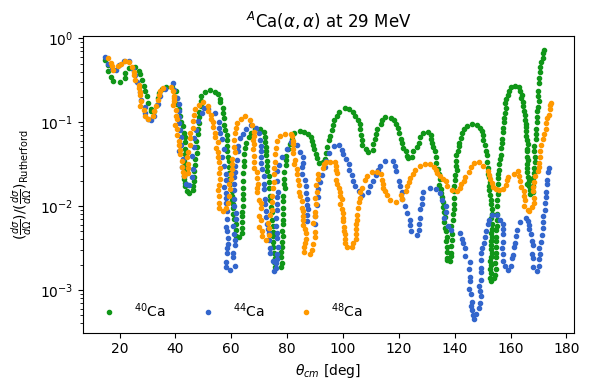

In [4]:
plt.figure(figsize=(6, 4))
for key, dataset in data.items():
    plt.plot(dataset["x"], dataset["y"], linestyle="none", marker=".", label=isotope_label[key], color=colors[key])

plt.yscale("log")
plt.legend(ncol=3, framealpha=0)
plt.xlabel(r"$\theta_{cm}$ [deg]")
plt.ylabel(r"$(\frac{d\sigma}{d\Omega}) / (\frac{d\sigma}{d\Omega})_\text{Rutherford}$")
plt.title(r"$^{A}$Ca($\alpha,\alpha$) at 29 MeV")
plt.tight_layout()
plt.show()

Notice the experimental evidence for trend highlighted in the paper - closed shell $^{48}$Ca and expecially $^{40}$Ca have very enhanced elastic cross sections at backwards angles, relative to the mid-shell $^{44}$Ca. 

## Compile the solver

Each target gets its own solver, evaluated on the angles at which that target was measured. Building a solver compiles code, so we do it once here and keep the objects around.

In [5]:
from jitr.rmatrix import Solver as SolverKernel
from jitr.utils import utils
from jitr.xs import elastic

lmax = 60


def build_solver(key, angles_deg):
    A, Z = targets[key]
    interaction_range_fm = 1.2 * (A ** (1 / 3) + 4 ** (1 / 3)) + 2
    channel_radius_dimensionless = utils.suggested_dimensionless_channel_radius(
        interaction_range_fm, kinematics[key].k
    )
    channel_radius = channel_radius_dimensionless / kinematics[key].k
    N = utils.suggested_basis_size(channel_radius_dimensionless, zeros_per_node=8)
    print(f"Compiling solver for {reactions[key]} at {energy_lab} MeV: "
          f"channel radius {channel_radius:1.2f} fm, {N} nodes, {lmax} partial waves")
    return elastic.DifferentialWorkspace.build_from_system(
        reaction=reactions[key],
        kinematics=kinematics[key],
        channel_radius_fm=channel_radius,
        solver=SolverKernel(N),
        lmax=lmax,
        angles=np.deg2rad(angles_deg),
    )


solvers = {key: build_solver(key, data[key]["x"]) for key in targets}

Compiling solver for 40-Ca(alpha,el) at 29 MeV: channel radius 10.94 fm, 64 nodes, 60 partial waves
Compiling solver for 44-Ca(alpha,el) at 29 MeV: channel radius 11.05 fm, 64 nodes, 60 partial waves
Compiling solver for 48-Ca(alpha,el) at 29 MeV: channel radius 11.15 fm, 64 nodes, 60 partial waves


In [6]:
# jit warmup - do this before forking worker processes later so they inherit compiled code
for solver in solvers.values():
    _ = solver.xs(central_potential=np.zeros_like(solver.radial_grid()))

## Define the interaction model and parameters

A real volume Woods-Saxon, an imaginary volume term and an imaginary surface term, plus the Coulomb potential of a uniformly charged sphere. The seven free parameters are the depths $V$, $W_v$, $W_s$ and the geometry $r_v, a_v, r_w, a_w$ (radii in units of $A^{1/3}$ fm; the surface term shares the imaginary geometry).

In [7]:
from jitr.optical_potentials.potential_forms import (
    coulomb_charged_sphere as coulomb,
    woods_saxon_safe as ws,
    woods_saxon_prime_safe as wsp,
)


def U_central(r, Vv, Wv, Ws, Rv, av, Rw, aw):
    return -Vv * ws(r, Rv, av) - 1j * Wv * ws(r, Rw, aw) - 1j * Ws * (-4 * aw) * wsp(r, Rw, aw)


def calculate_xs_ratio(theta, key):
    """Ratio to Rutherford on the data angles of `key` for optical model parameters `theta`."""
    solver = solvers[key]
    reaction = reactions[key]
    # each solver has its own radial quadrature grid (it depends on the channel radius)
    rgrid = solver.radial_grid()
    Vv, Wv, Ws, rv, av, rw, aw = theta
    A_factor = reaction.target.A ** (1 / 3)
    Zz = reaction.target.Z * reaction.projectile.Z
    xs = solver.xs(
        central_potential=U_central(rgrid, Vv, Wv, Ws, rv * A_factor, av, rw * A_factor, aw),
        coulomb_potential=coulomb(rgrid, Zz, 1.3 * A_factor),
    )
    return xs.dsdo / solver.rutherford


names = ["Vv", "Wv", "Ws", "rv", "av", "rw", "aw"]
labels = [r"$V$", r"$W_v$", r"$W_s$", r"$r_v$", r"$a_v$", r"$r_w$", r"$a_w$"]
n_omp = len(names)

## The error model

We do not know the experimental uncertainties, and the optical model is not a perfect description of the reaction, so we need a model for the residuals $\epsilon_i \equiv y_i - f(\theta_i;\alpha)$, where $f(\theta;\alpha) \equiv f_i$ is the model prediction at angle $\theta_i^{cm}$, for OMP parameters $\alpha$.

We put a multivariate Gaussian prior on the residuals, $\boldsymbol{\epsilon} | b , s \sim \mathcal{N}(0,\boldsymbol{\Sigma}(b,s))$ with covariance

$$
\Sigma_{ij} = s^2 f(\theta_i;\alpha) f(\theta_j;\alpha)\, \delta_{ij} + b^2 f(\theta_i;\alpha) f(\theta_j;\alpha) ,
$$

introducing two unknown parameters: $s$ is a **relative error, uncorrelated from point to point**, and $b$ is a **relative error common to all points**. The former acts like a relative statistical uncertainty, the latter like an uncertainty in the overall normalization, or more generally a coherent misfit of the model.

The data span four decades and the natural errors are multiplicative, so we evaluate the likelihood in log space, $r_i = \log y_i - \log f_i$. Take the two error sources to be independent lognormal factors, so we have $y_i = f_i\, A_i\, B$ with:
- $\mathbb{E} \left[ A_i \right]  = \mathbb{E} \left[ B \right] = 1$,
- $\mathrm{Var}[B] = b^2$
- $\mathrm{Var}[A_i] = \frac{s^2}{1+b^2}$ - the same for every point,

which reproduces $\Sigma$ in linear space exactly:

$$
\mathrm{Var}[y_i] = f_i^2[(1 + \mathrm{Var}A_i)(1 + \mathrm{Var}B) - 1] = (s^2 + b^2) f_i^2
$$

$$
\mathrm{Cov}[y_i, y_j] = b^2 f_i f_j,
$$

and gives a *homeoscedastic* (the same at all points $x_i$) error model in log space

$$
\Sigma^{\log}_{ij} = \delta_{ij} \log\!\left(1 + \frac{s^2}{1 + b^2}\right) + \log\!\left(1 + b^2\right) ,
$$

Such a diagonal-plus-rank-one matrix can be inverted with the [Sherman-Morrison formula](https://en.wikipedia.org/wiki/Sherman%E2%80%93Morrison_formula), and its determinant follows from the [matrix determinant lemma](https://en.wikipedia.org/wiki/Matrix_determinant_lemma), so the likelihood costs $O(N)$ - no dense solve required.

The log-likelihood is therefore

$$
-\frac{1}{2}\left(r^T (\Sigma^{\log})^{-1} r + \log\det \Sigma^{\log} + N\log 2\pi\right) - \sum_i \log y_i.
$$

The last term is the Jacobian that makes this a density for the data $y$ rather than for $\log y$. It is a constant (not $\alpha$, $b$, or $s$ dependent) here, but keeping it makes the evidence comparable to a linear-space likelihood.

In [8]:
ERR_NAMES = ["log_s", "log_b"]
ERR_LABELS = [r"$s$", r"$b$"]
n_err = len(ERR_NAMES)
ndim = n_omp + n_err
all_labels = labels + ERR_LABELS


def unpack(theta):
    return theta[:n_omp], np.exp(theta[n_omp:])  # potential parameters, (s, b)


def log_likelihood(theta, key):
    omp, (s, b) = unpack(theta)
    y = data[key]["y"]
    if np.any(omp[3:] <= 0):  # radii and diffusenesses must be positive
        return -1e300
    f_pred = calculate_xs_ratio(omp, key)  # f_i = f(theta_i; alpha)
    if np.any(f_pred <= 0) or not np.all(np.isfinite(f_pred)):
        return -1e300
    log_residuals = np.log(y) - np.log(f_pred)  # r_i = log y_i - log f_i
    n_pts = log_residuals.size

    # Sigma^log = d I + beta 11^T - homoscedastic, because both error terms are relative
    common_log_var = np.log1p(b**2)  # beta, added to every entry by the shared factor B
    point_log_var = np.log1p(s**2 / (1 + b**2))  # d, from the independent factors A_i

    # Sherman-Morrison:
    # r^T (Sigma^log)^-1 r = (r^T r)/d - beta (1^T r)^2 / (d (d + N beta))
    shared_term_denom = point_log_var + n_pts * common_log_var  # d + N beta
    mahalanobis = (
        log_residuals @ log_residuals / point_log_var
        - common_log_var * np.sum(log_residuals) ** 2 / (point_log_var * shared_term_denom)
    )
    # matrix determinant lemma: det(Sigma^log) = d^(N-1) (d + N beta)
    log_det = (n_pts - 1) * np.log(point_log_var) + np.log(shared_term_denom)

    jacobian = -np.sum(np.log(y))  # density for y, not log y
    return -0.5 * (mahalanobis + log_det + n_pts * np.log(2 * np.pi)) + jacobian


def predictive_draw(s, b, f_pred, rng):
    """One synthetic data set drawn from the error model around the model prediction f_pred."""
    # log y_i = log f_i + independent relative scatter (A_i) + one shared relative shift (B)
    log_noise = (
        np.sqrt(np.log1p(s**2 / (1 + b**2))) * rng.normal(size=f_pred.shape)
        + np.sqrt(np.log1p(b**2)) * rng.normal()
    )
    return f_pred * np.exp(log_noise)

## Prior

We take, for each isotope, a Gaussian prior wide enough ($\sim$20 MeV in $V$, 0.2 fm in the diffusenesses, 0.3 $A^{1/3}$ fm $\approx$ 1 fm in the radii) to let the data move the parameters freely and to admit the continuous $V$-$r_v$ ambiguity, while resolving any multi-modality in $V$. We center the prior on physically resonable numbers, which encode our physical observation that $^{44}$Ca is more absorbing. We will truncate the prior for each parameter at 0 on physical bounds (purely attractive and absorbing potential, and distances $R_{v/w}$ and $a_{v/w}$ strictly positive), but we wont force upper bounds.

The error scales are unknown by orders of magnitude, so they get wide log-uniform priors centered at 5% and are sampled as logarithms.

In [9]:
prior_center = {
    "Ca40": np.array([160, 15, 10, 1.4, 0.5, 1.4, 0.3]),
    "Ca44": np.array([150, 20, 20, 1.4, 0.5, 1.4, 0.3]),
    "Ca48": np.array([200, 15, 10, 1.4, 0.5, 1.4, 0.3]),
}
prior_std = np.array([20, 10, 10, 0.3, 0.2, 0.3, 0.2])

omp_prior = {
    key: stats.truncnorm(a=-center / prior_std, b=np.inf, loc=center, scale=prior_std)
    for key, center in prior_center.items()
}

err_prior = [
    stats.loguniform(5e-2, 2.0),  # s: relative, point-to-point independent error
    stats.loguniform(5e-2, 2.0),  # b: relative, fully correlated error
]


def prior_transform(u, key):
    omp = omp_prior[key].ppf(u[:n_omp])
    err = [np.log(p.ppf(ui)) for p, ui in zip(err_prior, u[n_omp:])]
    return np.concatenate([omp, err])

## Sampling the posterior

There are many third party libraries that can sample a posterior distribution given a likeihood and prior. We will use a neat one: [dynesty](https://dynesty.readthedocs.io/en/stable/quickstart.html), which does something called [nested sampling](https://en.wikipedia.org/wiki/Nested_sampling_algorithm), which has the advantages that it
- naturally handles multimodal posteriors
- computes the Bayesian evidence along with the prior for free

Each likelihood evaluation is an R-matrix solve, a few milliseconds, and independent of the others, so we hand `dynesty` a `multiprocessing` pool (`fork` so that the workers inherit the compiled solvers; Linux/macOS only). Expect $\sim$ 10  minutes per isotope with 4 independent processes.


In [10]:
import multiprocessing
from functools import partial

import dynesty

n_workers = min(4, os.cpu_count())
nlive = 50 if QUICK else 250
dlogz = 5.0 if QUICK else 1.0
print(f"Using {n_workers} worker processes, nlive={nlive}, dlogz={dlogz}")

Using 4 worker processes, nlive=250, dlogz=1.0


In [11]:
%%time
results = {}
with multiprocessing.get_context("fork").Pool(n_workers) as pool:
    for key in targets:
        sampler = dynesty.NestedSampler(
            partial(log_likelihood, key=key),
            partial(prior_transform, key=key),
            ndim,
            nlive=nlive,
            sample="rwalk",
            pool=pool,
            queue_size=n_workers,
            rstate=np.random.default_rng(0),
        )
        sampler.run_nested(dlogz=dlogz, print_progress=False)
        results[key] = sampler.results
        print(f"{key}: log Z = {results[key].logz[-1]:.2f} +/- {results[key].logzerr[-1]:.2f}, "
              f"{int(np.sum(results[key].ncall))} calls, efficiency {results[key].eff:.1f} %")


Ca40: log Z = 813.43 +/- 0.69, 208615 calls, efficiency 3.8 %
Ca44: log Z = 924.54 +/- 0.63, 164178 calls, efficiency 3.9 %
Ca48: log Z = 860.74 +/- 0.72, 244212 calls, efficiency 3.8 %
CPU times: user 37.8 s, sys: 2.88 s, total: 40.7 s
Wall time: 1h 7min 55s


Now, for each system, we take our posterior samples, and make draws from the posterior predictive distribution $p(\boldsymbol{f}(\alpha) + \boldsymbol{\epsilon}(a,b) | \boldsymbol{y} )$ by pushing those optical potential samples back through `jitr` to get cross sections, and then through our error model.

In [12]:
%%time
n_draws = 100 if QUICK else 300
n_noise_replicates = 4
rng = np.random.default_rng(42)

posterior_samples = {}  # equally weighted samples (all)
posterior_draws = {}  # subset used for predictions
posterior_model = {}  # model curves for the subset
posterior_predictive = {}  # model + error model, for the data
for key, res in results.items():
    samples = res.samples_equal(rstate=rng)
    posterior_samples[key] = samples
    draws = samples[rng.choice(len(samples), size=min(n_draws, len(samples)), replace=False)]
    posterior_draws[key] = draws
    posterior_model[key] = np.array([calculate_xs_ratio(unpack(s)[0], key) for s in draws])
    posterior_predictive[key] = np.array([
        predictive_draw(*unpack(s)[1], m, rng)
        for _ in range(n_noise_replicates) for s, m in zip(draws, posterior_model[key])
    ])


CPU times: user 10.8 s, sys: 2.84 ms, total: 10.8 s
Wall time: 10.8 s


## Posterior distributions

First the seven potential parameters for the three isotopes on one corner plot. Within each isotope the expected $V$-$r_v$ anticorrelation is visible. Look at the $V$ column: for $^{40}$Ca the data have pulled $V$ some 25 MeV (more than one prior width) away from the prior centre, and $r_v$ with it along the ambiguity.

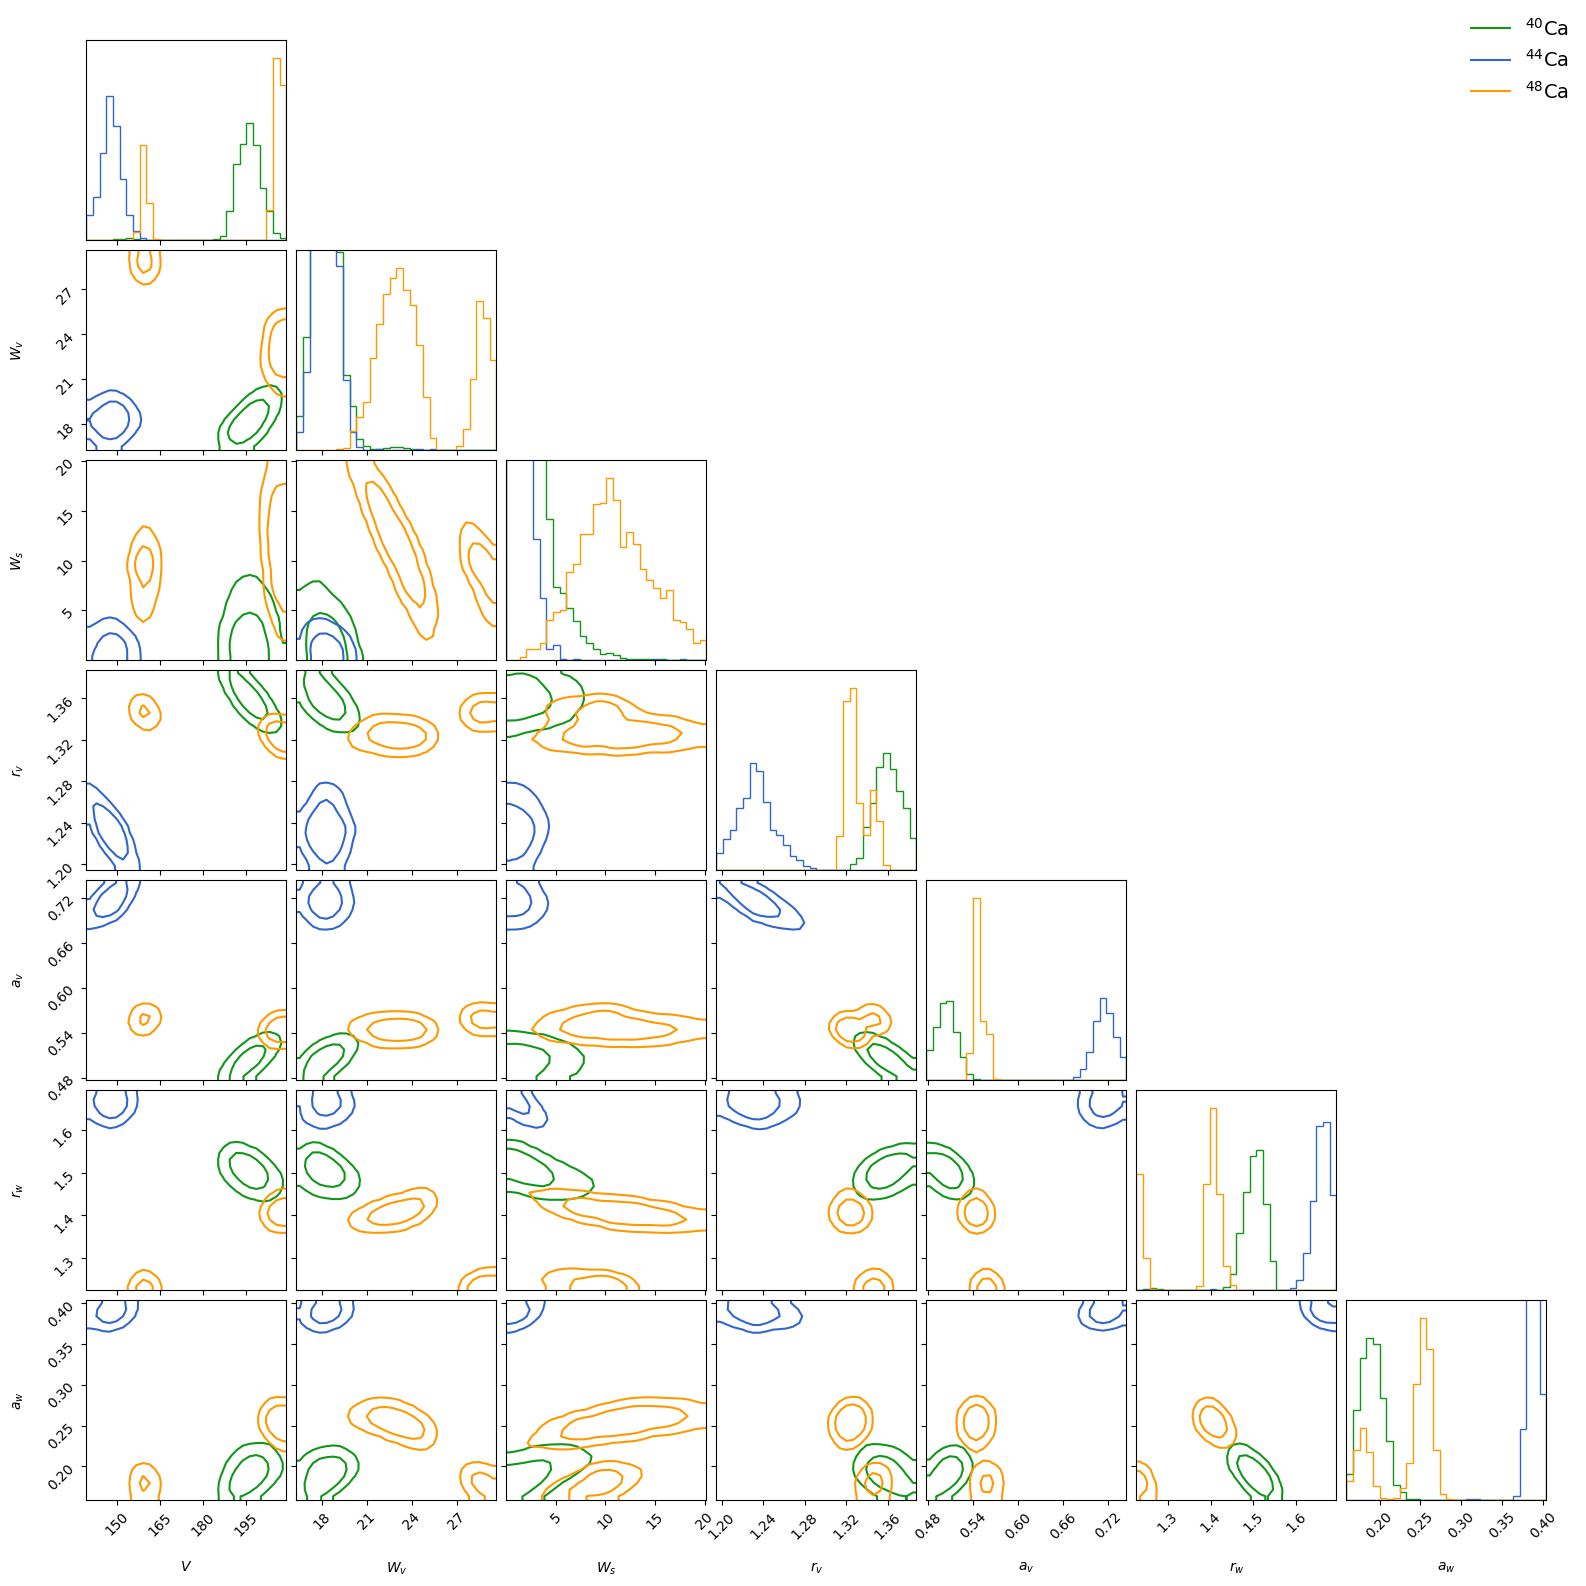

In [13]:
import corner
from matplotlib.lines import Line2D


def corner_overlay(samples, labels, keys, ranges=None, **kwargs):
    """Overlay corner plots for several isotopes with a common range."""
    if ranges is None:
        allsamples = np.vstack([samples[key] for key in keys])
        ranges = list(zip(np.percentile(allsamples, 0.5, axis=0), np.percentile(allsamples, 99.5, axis=0)))
    fig = None
    for key in keys:
        fig = corner.corner(
            samples[key],
            labels=labels,
            color=colors[key],
            fig=fig,
            range=ranges,
            bins=30,
            smooth=1.0,
            plot_datapoints=False,
            plot_density=False,
            levels=(0.68, 0.95),
            hist_kwargs={"density": True},
            **kwargs,
        )
    fig.legend(
        handles=[Line2D([], [], color=colors[key], label=isotope_label[key]) for key in keys],
        loc="upper right", fontsize=14, framealpha=0,
    )
    return fig


omp_samples = {key: posterior_samples[key][:, :n_omp] for key in targets}
fig = corner_overlay(omp_samples, labels, list(targets))
plt.show()

Then the two error scales, transformed back from their logarithms.

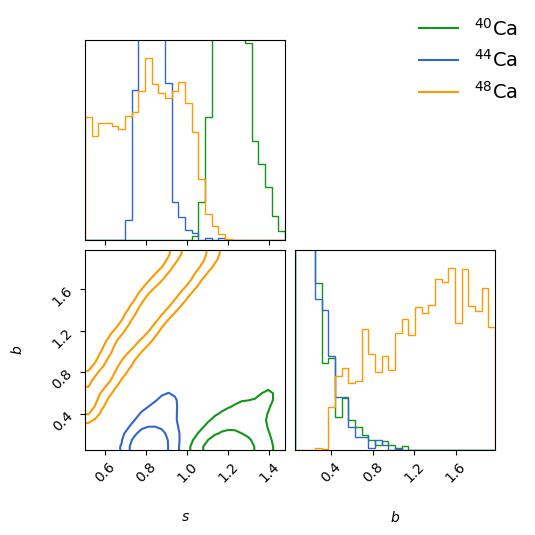

In [14]:
err_samples = {key: np.exp(posterior_samples[key][:, n_omp:]) for key in targets}
fig = corner_overlay(err_samples, ERR_LABELS, list(targets))
plt.show()


We now build a table of medians and central 68% intervals for everything, as well as calculate the volume integrals:

$$
\frac{J_U}{4A} = \frac{4\pi}{4A}\int_0^\infty U(r)\, r^2\, dr .
$$


In [27]:
def volume_integral_per_nucleon(samples, key):
    """J_V / (4 A) [MeV fm^3] for each posterior sample."""
    A = targets[key][0]
    r = np.linspace(0, 20, 2000)
    out = np.zeros(len(samples), dtype=complex)
    for i, (Vv, Wv, Ws, rv, av, rw, aw) in enumerate(samples[:, :n_omp]):
        Rv = rv * A ** (1 / 3)
        Rw = rw * A **(1/3)
        out[i] += np.trapezoid(Vv * ws(r, Rv, av) * r**2, r) 
        out[i] += 1j * np.trapezoid( (Wv * ws(r, Rw, aw) - Ws * (-4 * aw) * wsp(r, Rw, aw)) * r**2, r)

    return 4 * np.pi / (4 *  A) *  out


jv_samples = {key: volume_integral_per_nucleon(posterior_samples[key], key) for key in targets}


def summarize(samples):
    q = np.percentile(samples, [16, 50, 84], axis=0)
    return [f"{m:.3g} [{lo:.3g}, {hi:.3g}]" for lo, m, hi in q.T]


pd.DataFrame(
    {
        isotope_label[key]: summarize(np.column_stack([posterior_samples[key][:, :n_omp], err_samples[key], jv_samples[key].real, jv_samples[key].imag, ]))
        for key in targets
    },
    index=names + [n.removeprefix("log_") for n in ERR_NAMES] + ["J_V/4A [MeV fm^3]"]+ ["J_W/4A [MeV fm^3]"],
)


,$^{40}$Ca,$^{44}$Ca,$^{48}$Ca
Vv,"196 [192, 200]","148 [144, 151]","206 [160, 207]"
Wv,"18.1 [17.4, 19.1]","18.3 [17.6, 19]","23.6 [22, 28.6]"
Ws,"2.19 [0.793, 4.53]","1.25 [0.446, 2.33]","10.7 [7.34, 15.1]"
rv,"1.36 [1.35, 1.38]","1.23 [1.21, 1.25]","1.33 [1.32, 1.35]"
av,"0.503 [0.49, 0.517]","0.715 [0.702, 0.73]","0.546 [0.541, 0.557]"
rw,"1.5 [1.48, 1.53]","1.66 [1.64, 1.68]","1.4 [1.24, 1.42]"
aw,"0.19 [0.176, 0.205]","0.389 [0.382, 0.396]","0.25 [0.181, 0.261]"
s,"1.21 [1.15, 1.3]","0.823 [0.78, 0.874]","0.81 [0.603, 0.982]"
b,"0.109 [0.0629, 0.256]","0.133 [0.0765, 0.271]","1.36 [0.768, 1.77]"
J_V/4A [MeV fm^3],"577 [573, 580]","367 [364, 370]","564 [461, 567]"


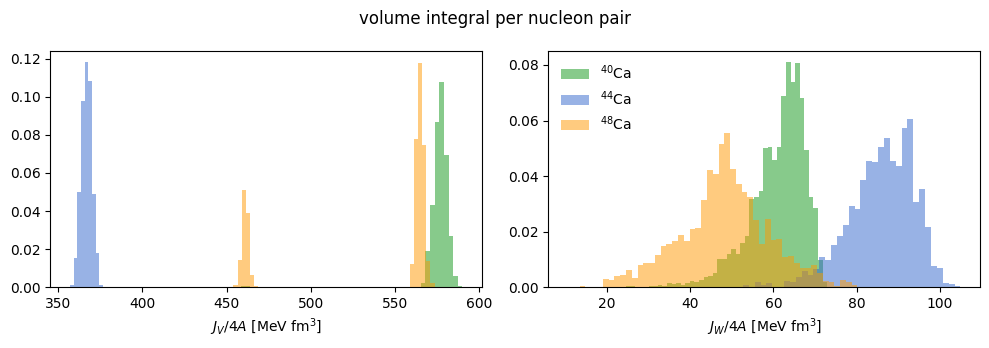

In [28]:
fig, axes =  plt.subplots(1,2, figsize=(10, 3.5))
for key in targets:
    axes[0].hist(jv_samples[key].real, bins=50, density=True, color=colors[key], alpha=0.5, label=isotope_label[key])
    axes[1].hist(jv_samples[key].imag, bins=50, density=True, color=colors[key], alpha=0.5, label=isotope_label[key])

axes[0].set_xlabel(r"$J_V / 4A$ [MeV fm$^3$]")
axes[1].set_xlabel(r"$J_W / 4A$ [MeV fm$^3$]")
axes[1].legend(framealpha=0)

fig.suptitle("volume integral per nucleon pair")
plt.tight_layout()
plt.show()

Note that, as we expected, the imaginary volume integral is statistically much larger for the mid-shell $^{44}$Ca.

## Posterior predictive distributions

Propagating posterior samples through the model gives the spread of *model* curves; adding a draw from the error model on top gives the posterior predictive distribution for the *data*, which is what should be compared to the points.

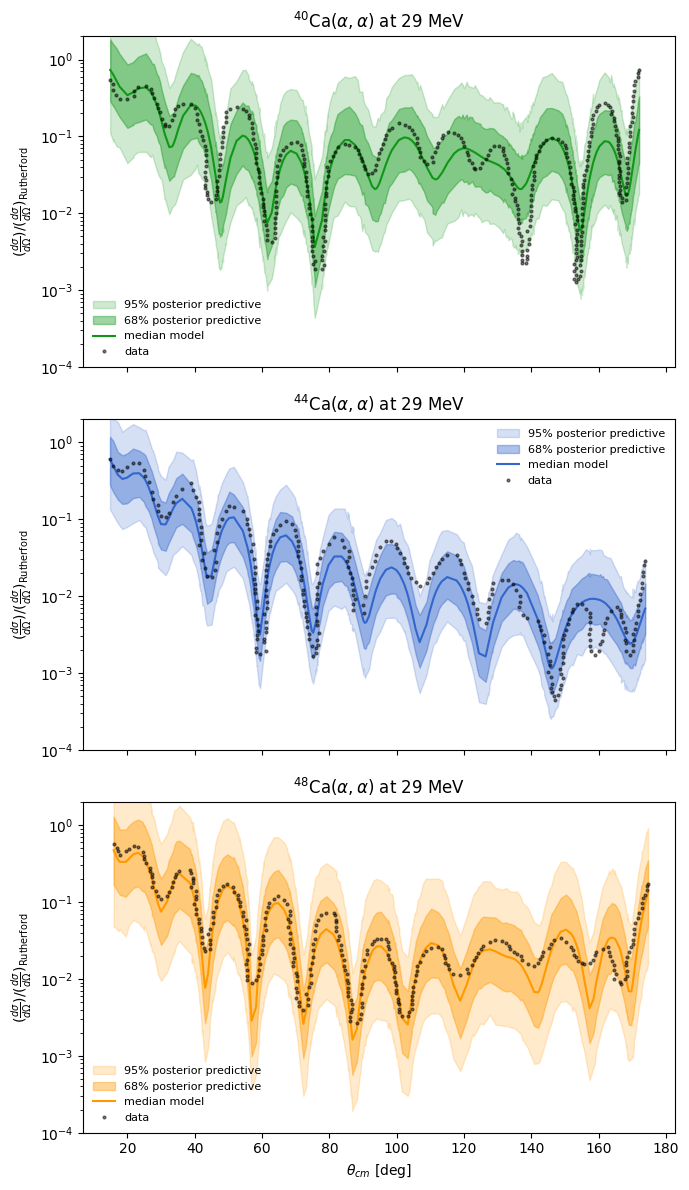

In [17]:
def plot_predictive(ax, key, label=None):
    x = data[key]["x"]
    pred = np.clip(posterior_predictive[key], 1e-6, None)
    lo95, lo68, hi68, hi95 = np.percentile(pred, [2.5, 16, 84, 97.5], axis=0)
    ax.fill_between(x, lo95, hi95, color=colors[key], alpha=0.2, label="95% posterior predictive")
    ax.fill_between(x, lo68, hi68, color=colors[key], alpha=0.4, label="68% posterior predictive")
    ax.plot(x, np.median(posterior_model[key], axis=0), color=colors[key], linewidth=1.5, label="median model")
    ax.plot(x, data[key]["y"], ".", color="k", alpha=0.5, markersize=4, label="data")
    ax.set_yscale("log")
    ax.set_ylim(1e-4, 2)
    ax.set_ylabel(r"$(\frac{d\sigma}{d\Omega}) / (\frac{d\sigma}{d\Omega})_\text{Rutherford}$")
    ax.set_title(label or rf"{isotope_label[key]}($\alpha,\alpha$) at 29 MeV")
    ax.legend(framealpha=0, fontsize=8)


fig, axes = plt.subplots(len(targets), 1, figsize=(7, 4 * len(targets)), sharex=True)
for ax, key in zip(axes, targets):
    plot_predictive(ax, key)
axes[-1].set_xlabel(r"$\theta_{cm}$ [deg]")
plt.tight_layout()
plt.show()

## Empirical coverage

If the error model is right, the central $q$ credible interval of the posterior predictive distribution should contain a fraction $q$ of the data points, for every $q$. Plotting the fraction actually covered against $q$ is a direct check of the calibration of the whole model, potential and error model together.

Ca40: coverage at 68% = 0.70, at 95% = 0.94, mean |coverage - credibility| = 0.052
Ca44: coverage at 68% = 0.69, at 95% = 0.98, mean |coverage - credibility| = 0.020
Ca48: coverage at 68% = 0.94, at 95% = 1.00, mean |coverage - credibility| = 0.237


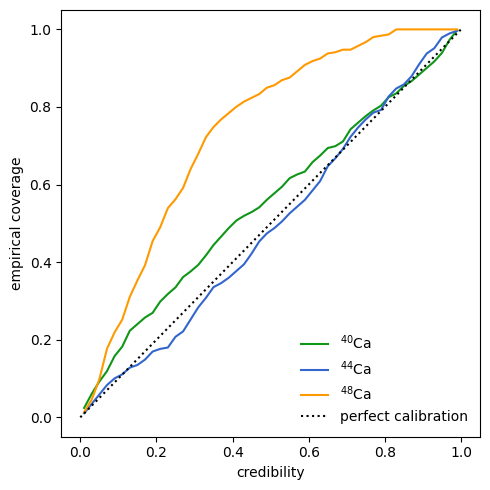

In [18]:
credibility = np.linspace(0.01, 0.99, 50)


def empirical_coverage(pred, y, q):
    lo, hi = np.percentile(pred, [50 * (1 - q), 50 * (1 + q)], axis=0)
    return np.mean((y >= lo) & (y <= hi))


plt.figure(figsize=(5, 5))
for key in targets:
    coverage = np.array([empirical_coverage(posterior_predictive[key], data[key]["y"], q) for q in credibility])
    plt.plot(credibility, coverage, color=colors[key], label=isotope_label[key])
    print(f"{key}: coverage at 68% = {empirical_coverage(posterior_predictive[key], data[key]['y'], 0.68):.2f}, "
          f"at 95% = {empirical_coverage(posterior_predictive[key], data[key]['y'], 0.95):.2f}, "
          f"mean |coverage - credibility| = {np.mean(np.abs(coverage - credibility)):.3f}")
plt.plot([0, 1], [0, 1], "k:", label="perfect calibration")
plt.xlabel("credibility")
plt.ylabel("empirical coverage")
plt.legend(framealpha=0)
plt.tight_layout()
plt.show()


## Summary

We have used `jitr` to a do a full Bayesian calibration of the optical model potentials for $\alpha$s on Ca isotopes, with uncertainty quantified resolution of shell effects.  